Known x values:
[0. 1. 2. 3. 4. 5.]

Known y values:
[1. 2. 0. 2. 3. 2.]

Step sizes h:
[1. 1. 1. 1. 1.]

Second derivatives M:
[ 0.     -6.6029  8.4115 -3.0431 -2.2392  0.    ]


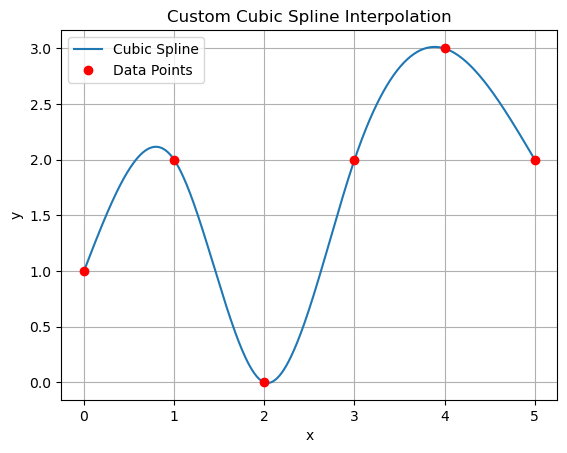

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ChatGPT was used to help organize the cubic spline steps
# and clean up the Thomas algorithm portion.

# known data points
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([1, 2, 0, 2, 3, 2], dtype=float)

def thomas_algorithm(a, b, c, d):
    n = len(d)
    c_star = np.zeros(n)
    d_star = np.zeros(n)
    sol = np.zeros(n)

    c_star[0] = c[0] / b[0]
    d_star[0] = d[0] / b[0]

    for i in range(1, n):
        denom = b[i] - a[i] * c_star[i - 1]
        c_star[i] = c[i] / denom if i < n - 1 else 0
        d_star[i] = (d[i] - a[i] * d_star[i - 1]) / denom

    sol[-1] = d_star[-1]
    for i in range(n - 2, -1, -1):
        sol[i] = d_star[i] - c_star[i] * sol[i + 1]

    return sol

def cubic_spline_setup(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n)
    B = np.zeros(n)
    C = np.zeros(n)
    D = np.zeros(n)

    B[0] = 1
    B[-1] = 1

    for i in range(1, n - 1):
        A[i] = h[i - 1]
        B[i] = 2 * (h[i - 1] + h[i])
        C[i] = h[i]
        D[i] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    M = thomas_algorithm(A, B, C, D)
    return h, M

def evaluate_spline(x, y, M, xeval):
    yeval = np.zeros_like(xeval)

    for j, xv in enumerate(xeval):
        for i in range(len(x) - 1):
            if x[i] <= xv <= x[i + 1]:
                h = x[i + 1] - x[i]

                term1 = M[i] * (x[i + 1] - xv) ** 3 / (6 * h)
                term2 = M[i + 1] * (xv - x[i]) ** 3 / (6 * h)
                term3 = (y[i] - M[i] * h ** 2 / 6) * (x[i + 1] - xv) / h
                term4 = (y[i + 1] - M[i + 1] * h ** 2 / 6) * (xv - x[i]) / h

                yeval[j] = term1 + term2 + term3 + term4
                break

    return yeval

# step sizes and second derivatives
h, M = cubic_spline_setup(x, y)

# new x points for smooth curve
xeval = np.linspace(x[0], x[-1], 400)
yeval = evaluate_spline(x, y, M, xeval)

print("Known x values:")
print(x)
print("\nKnown y values:")
print(y)
print("\nStep sizes h:")
print(h)
print("\nSecond derivatives M:")
print(np.round(M, 4))

# ChatGPT was also used to help format the print output and plotting cleanly.
plt.plot(xeval, yeval, label='Cubic Spline')
plt.plot(x, y, 'ro', label='Data Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Custom Cubic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()